# Exercise for Graph 4

Make the graph on the right! You will need to make use of  2 conditional edges!

Input: initial_state = AgentState(number1 = 10 , operation="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber = 0,finalNumber2 = 0)


In [1]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph

In [4]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation: str
    operation2: str
    finalNumber: int
    finalNumber2: int

In [7]:
def adder1(state:AgentState) -> AgentState:
    """This is the fist node that adds 2 numbers"""

    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def adder2(state:AgentState) -> AgentState:
    """This is the second node that adds 2 numbers"""

    state["finalNumber2"] = state["finalNumber"] + state["number3"] + state["number4"]
    return state

In [19]:
def substractor1(state:AgentState) -> AgentState:
    """This is the fist node that substracts 2 numbers"""

    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def substractor2(state:AgentState) -> AgentState:
    """This is the second node that substracts 2 numbers"""

    state["finalNumber2"] = state["finalNumber"] - state["number3"] - state["number4"]
    return state

In [11]:
def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next ndoe of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    
    elif state["operation"] == "-":
        return "substraction_operation"

In [13]:
def decide_next_node2(state:AgentState) -> AgentState:
    """This node will select the next ndoe of the graph"""

    if state["operation2"] == "+":
        return "addition_operation"
    
    elif state["operation2"] == "-":
        return "substraction_operation"

In [20]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder1)
graph.add_node("substract_node", substractor1)
graph.add_node("add_node2", adder2)
graph.add_node("substract_node2", substractor2)
graph.add_node("router", lambda state:state)
graph.add_node("router2", lambda state:state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "substraction_operation": "substract_node"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("substract_node", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation": "add_node2",
        "substraction_operation": "substract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("substract_node2", END)

app = graph.compile()


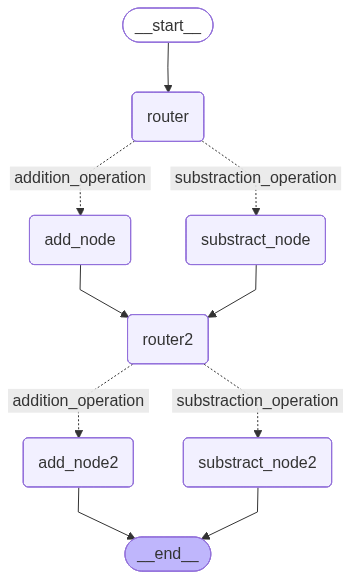

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
input2 = AgentState(number1 = 10 , operation="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber = 0,finalNumber2 = 0)

result = app.invoke(input2)

print(result["finalNumber2"])

14
